# Assignment-2: Implementing and Analyzing Variational Autoencoder (VAE)

**Course:** CS772  
**Submission:** (1) this completed `.ipynb` notebook, and (2) a separate PDF containing all derivations and written answers. The PDF has to be uploaded on **Gradescope** and the notebook has to be uploaded as a **zip file** on the following **Dropbox** link: https://www.dropbox.com/request/br97unrk59kal356hnpf

## Background and Notation

We observe data $x \in \mathbb{R}^D$ and posit a latent variable model:

$$p_\theta(x, z) = p_\theta(x|z)\, p(z)$$

where $p(z) = \mathcal{N}(0, I)$ is a fixed standard normal prior and $p_\theta(x|z)$ is a learned decoder. We want to maximize $\log p_\theta(x)$, but the integral $\int p_\theta(x|z)\,p(z)\,dz$ is intractable.

The VAE (Kingma & Welling, 2013) introduces a learned approximate posterior $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x),\, \mathrm{diag}(\sigma^2_\phi(x)))$, whose parameters are output by an encoder network. Applying Jensen's inequality yields the **Evidence Lower BOund (ELBO)**:

$$\log p_\theta(x) \;\geq\; \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction term}} \;-\; \underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right)}_{\text{Regularization term}} \;=:\; \mathcal{L}(\theta, \phi; x)$$

Training maximizes the ELBO jointly over $\theta$ and $\phi$.

> **Notation:** The encoder outputs two $d$-dimensional vectors: $\mu$ (mean) and $\log\sigma^2$ (log-variance `logvar`).

---
## Setup

In [5]:

import torch, random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = hash("CS772")% (2**32)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
Z_DIM      = 10
EPOCHS     = 10
LR         = 1e-3

transform     = transforms.ToTensor()   # pixels in [0, 1]
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Using device: {DEVICE}")

Using device: cpu


---
## Model Architecture

The encoder and decoder are defined as separate modules. The `VAE` class composes them and implements the reparameterization trick.

In [8]:
class Encoder(nn.Module):
    """
    Maps a flat input x (784-d) to the parameters of q_φ(z|x):
    a mean vector μ and a log-variance vector log σ², each of shape (z_dim,).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, z_dim)
        self.fc_logvar = nn.Linear(256, z_dim)

    def forward(self, x):
        h = self.net(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

In [9]:
class Decoder(nn.Module):
    """
    Maps a latent vector z (z_dim-d) to a reconstructed image.
    Output is in [0, 1] via sigmoid — interpreted as the mean of p_θ(x|z).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),    # pixels in [0, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 28, 28)

In [11]:
class VAE(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        """
        TODO (Q2.1): Implement the reparameterization trick.

        Draw z ~ q_φ(z|x) = N(μ, diag(σ²)) in a way that allows
        gradients to flow back through z into μ and log σ².

        """
        std = torch.exp(0.5 * logvar)       # σ = exp(0.5 * log σ²)
        eps = torch.randn_like(std)          # ε ~ N(0, I)
        return mu + eps * std                # z = μ + ε ⊙ σ

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decoder(z)
        return recon_x, mu, logvar, z

---
## Part 1

### Q1.1  Reconstruction Loss (10 pts)

Assume the decoder models $p_\theta(x|z) = \mathcal{N}(f_\theta(z), \sigma^2 I)$, where $f_\theta(z)$ is the decoder output and $\sigma^2$ is a fixed constant.

1. Show algebraically that maximizing $\log p_\theta(x|z)$ under this Gaussian assumption is equivalent to minimizing the Mean Squared Error (MSE) between $x$ and $f_\theta(z)$.*

2. In practice we implement a deterministic decoder. The network outputs only the mean $f_\theta(z)$ and the variance is ignored. Briefly explain what this implies about the quality of VAE-generated images.

3. An alternative is to model each pixel as an independent Bernoulli: $p_\theta(x|z) = \prod_i \text{Bern}(x_i;\, \hat{x}_i)$. What loss function does this correspond to? Why might this be more principled for MNIST than MSE?

### Q1.2  Closed-Form KL Divergence (10 pts)

Given $q_\phi(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$ and $p(z) = \mathcal{N}(0, I)$, derive the following closed-form expression starting only from the definition of KL divergence:

$$D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$


---
## Part 2  Implementation

### Q2.1  Reparameterization (5 pts)

Implement `reparameterize` in the `VAE` class above and explain why this trick is necessary. What goes wrong if you write `z = torch.distributions.Normal(mu, sigma).sample()` and try to backpropagate.

### Q2.2  Loss Function (10 pts)

Implement the VAE loss below. Use **MSE** for the reconstruction term and the **closed-form KL** from Q1.2.

> **Reduction:** use `.sum(dim=1).mean()` — sum over pixels and latent dimensions, then average over the batch.

In [12]:
def vae_loss(recon_x, x, mu, logvar):
    """
    VAE ELBO loss (negated — we minimize this).

    Args:
        recon_x : (B, 784)        decoder output, pixel values in [0, 1]
        x       : (B, 1, 28, 28)  original images
        mu      : (B, z_dim)
        logvar  : (B, z_dim)      log σ²

    Returns:
        recon_l : scalar reconstruction term
        kl_l    : scalar KL term
    """
    x_flat = x.view(-1, 784)
    recon_flat = recon_x.view(-1, 784)
    # MSE reconstruction: sum over pixels, mean over batch
    recon_l = ((recon_flat - x_flat) ** 2).sum(dim=1).mean()
    # Closed-form KL: -0.5 * sum(1 + log σ² - μ² - σ²)
    kl_l = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return recon_l, kl_l

### Q2.3  Training Loop (5 pts)

Implement the training loop below. Log total loss, reconstruction loss, and KL loss separately each epoch. After training, plot all three on a single figure.

In [13]:
def train(model, optimizer, loss_fn, loader, epochs=10, beta=1.0):
    model.train()
    history = {'total': [], 'recon': [], 'kl': []}
    for epoch in range(1, epochs + 1):
        epoch_total, epoch_recon, epoch_kl, n_batches = 0, 0, 0, 0
        for x, _ in loader:
            x = x.to(next(model.parameters()).device)
            optimizer.zero_grad()
            recon_x, mu, logvar, z = model(x)
            recon_l, kl_l = loss_fn(recon_x, x, mu, logvar)
            loss = recon_l + beta * kl_l
            loss.backward()
            optimizer.step()
            epoch_total += loss.item()
            epoch_recon += recon_l.item()
            epoch_kl    += kl_l.item()
            n_batches   += 1
        history['total'].append(epoch_total / n_batches)
        history['recon'].append(epoch_recon / n_batches)
        history['kl'].append(epoch_kl / n_batches)
        print(f"Epoch {epoch}/{epochs} | Total: {history['total'][-1]:.4f} | "
              f"Recon: {history['recon'][-1]:.4f} | KL: {history['kl'][-1]:.4f}")
    return history

Epoch 1/10 | Total: 47.8097 | Recon: 44.7163 | KL: 3.0935
Epoch 2/10 | Total: 34.6402 | Recon: 27.2604 | KL: 7.3798
Epoch 3/10 | Total: 32.2482 | Recon: 23.8023 | KL: 8.4459
Epoch 4/10 | Total: 31.1490 | Recon: 22.2543 | KL: 8.8947
Epoch 5/10 | Total: 30.4832 | Recon: 21.3344 | KL: 9.1488
Epoch 6/10 | Total: 29.9802 | Recon: 20.6362 | KL: 9.3440
Epoch 7/10 | Total: 29.6115 | Recon: 20.0784 | KL: 9.5330
Epoch 8/10 | Total: 29.2989 | Recon: 19.6734 | KL: 9.6255
Epoch 9/10 | Total: 29.0375 | Recon: 19.2934 | KL: 9.7441
Epoch 10/10 | Total: 28.8298 | Recon: 18.9937 | KL: 9.8360


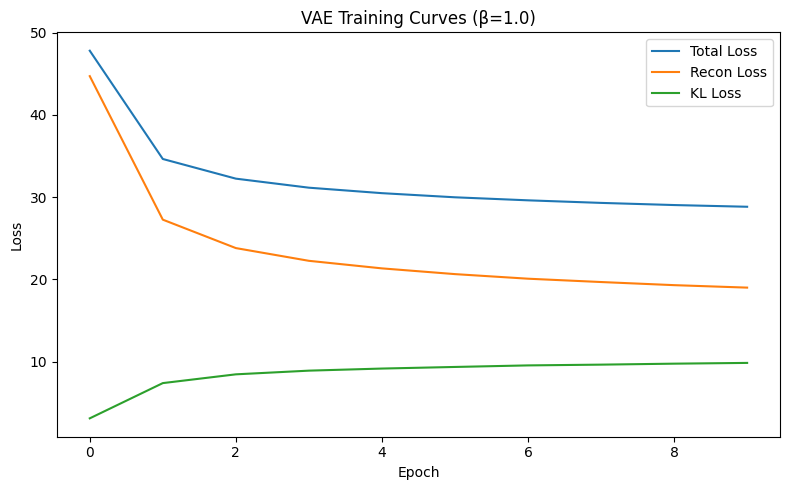

In [14]:
# Train the standard model (β = 1)

model     = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
hist = train(model, optimizer, vae_loss, train_loader)

# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist['total'], label='Total Loss')
ax.plot(hist['recon'], label='Recon Loss')
ax.plot(hist['kl'],    label='KL Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('VAE Training Curves (β=1.0)')
ax.legend(); plt.tight_layout(); plt.show()

### Q2.4  Monte Carlo KL Approximation (15 pts)

The KL term can be estimated without a closed form using Monte Carlo (MC) sampling:

$$D_{\mathrm{KL}}(q_\phi(z|x) \| p(z)) = \mathbb{E}_{q_\phi(z|x)}\!\left[\log q_\phi(z|x) - \log p(z)\right] \approx \frac{1}{L}\sum_{\ell=1}^{L}\left[\log q_\phi(z^{(\ell)}|x) - \log p(z^{(\ell)})\right]$$

where each $z^{(\ell)} \sim q_\phi(z|x)$ is drawn using the reparameterization trick.

1. Implement `vae_loss_mc` below. Draw $L$ samples *inside* the loss function. Use `torch.distributions.Normal` for the log-probability evaluations.
2. Train three fresh models using `vae_loss_mc` with $L \in \{1, 10, 100\}$. Plot the KL loss curves for all three alongside your closed-form baseline.
3.Describe qualitatively what you observe in the $L=1$ KL curve compared to $L=100$. Why is high variance in this gradient estimate specifically harmful during early training? Why would you prefer the closed form when it is available, even if $L$ is large?

In [15]:
def vae_loss_mc(recon_x, x, mu, logvar, L=1):
    """
    VAE loss with MC-estimated KL using L samples.

    Args:
        recon_x : (B, 784)
        x       : (B, 1, 28, 28)
        mu      : (B, z_dim)
        logvar  : (B, z_dim)
        L       : number of MC samples for the KL estimate

    Returns: (recon_l, kl_l)

    Hint: draw samples of shape (L, B, z_dim) using the reparameterization
    trick, evaluate log q and log p for each, and average over L.
    """
    x_flat = x.view(-1, 784)
    recon_flat = recon_x.view(-1, 784)
    recon_l = ((recon_flat - x_flat) ** 2).sum(dim=1).mean()

    B, d = mu.shape
    std = torch.exp(0.5 * logvar)  # (B, d)

    # Draw L samples: (L, B, d)
    eps = torch.randn(L, B, d, device=mu.device)
    z_samples = mu.unsqueeze(0) + eps * std.unsqueeze(0)  # (L, B, d)

    # log q(z|x) = log N(z; mu, diag(sigma^2))
    q_dist = torch.distributions.Normal(mu, std)  # batch shape (B, d)
    # Evaluate log prob for each sample: sum over d dimensions
    log_q = q_dist.log_prob(z_samples).sum(dim=-1)  # (L, B)

    # log p(z) = log N(z; 0, I)
    p_dist = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
    log_p = p_dist.log_prob(z_samples).sum(dim=-1)  # (L, B)

    # KL ≈ (1/L) Σ [log q - log p], then mean over batch
    kl_l = ((log_q - log_p).mean(dim=0)).mean()
    return recon_l, kl_l
  

Epoch 1/10 | Total: 47.7147 | Recon: 44.4578 | KL: 3.2569
Epoch 2/10 | Total: 34.5008 | Recon: 27.0466 | KL: 7.4542
Epoch 3/10 | Total: 32.3945 | Recon: 24.1308 | KL: 8.2637
Epoch 4/10 | Total: 31.2800 | Recon: 22.4686 | KL: 8.8114
Epoch 5/10 | Total: 30.4833 | Recon: 21.2939 | KL: 9.1894
Epoch 6/10 | Total: 29.9832 | Recon: 20.5046 | KL: 9.4787
Epoch 7/10 | Total: 29.5185 | Recon: 19.8918 | KL: 9.6266
Epoch 8/10 | Total: 29.1967 | Recon: 19.4324 | KL: 9.7643
Epoch 9/10 | Total: 28.9070 | Recon: 19.0219 | KL: 9.8851
Epoch 10/10 | Total: 28.6736 | Recon: 18.7295 | KL: 9.9441
Epoch 1/10 | Total: 47.4637 | Recon: 44.2367 | KL: 3.2270
Epoch 2/10 | Total: 34.5073 | Recon: 27.1016 | KL: 7.4056
Epoch 3/10 | Total: 32.4349 | Recon: 24.2862 | KL: 8.1487
Epoch 4/10 | Total: 31.3791 | Recon: 22.7402 | KL: 8.6389
Epoch 5/10 | Total: 30.6448 | Recon: 21.6160 | KL: 9.0288
Epoch 6/10 | Total: 30.1009 | Recon: 20.8164 | KL: 9.2845
Epoch 7/10 | Total: 29.6454 | Recon: 20.1610 | KL: 9.4843
Epoch 8/10 | 

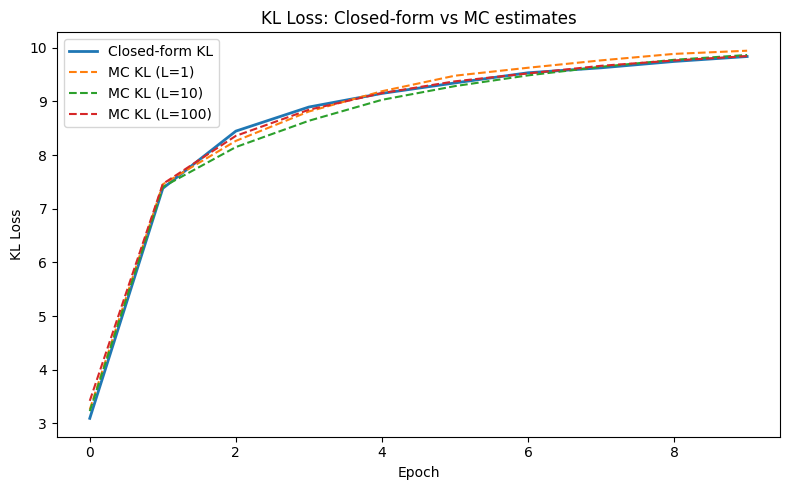

In [17]:
# Train with L = 1, 10, 100 and plot KL curves
# YOUR CODE HERE

import functools
kl_histories = {}
for L_val in [1, 10, 100]:
    model_mc = VAE().to(DEVICE)
    opt_mc = optim.Adam(model_mc.parameters(), lr=LR)
    loss_mc = functools.partial(vae_loss_mc, L=L_val)
    hist_mc = train(model_mc, opt_mc, loss_mc, train_loader)
    kl_histories[L_val] = hist_mc['kl']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist['kl'], label='Closed-form KL', linewidth=2)
for L_val, kl_curve in kl_histories.items():
    ax.plot(kl_curve, label=f'MC KL (L={L_val})', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('KL Loss')
ax.set_title('KL Loss: Closed-form vs MC estimates')
ax.legend(); plt.tight_layout(); plt.show()

---
## Part 3  $\beta$-VAE and Posterior Collapse

We introduce a scalar $\beta \geq 0$ weighting the KL term:

$$\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta \cdot D_{\mathrm{KL}}(q_\phi(z|x) \| p(z))$$

The standard VAE is $\beta = 1$. Higgins et al. (2017) showed $\beta > 1$ encourages disentangled representations at the cost of reconstruction quality.

### Q3.1  Training (5 pts)

Modify your training loop to accept `beta`. Train three models with $\beta \in \{0.1, 1.0, 10.0\}$ for `EPOCHS` epochs. Show plots of the reconstruction and KL loss curves for all three settings.

Epoch 1/10 | Total: 38.2574 | Recon: 36.7798 | KL: 14.7761
Epoch 2/10 | Total: 19.9789 | Recon: 17.5425 | KL: 24.3644
Epoch 3/10 | Total: 17.0420 | Recon: 14.5233 | KL: 25.1866
Epoch 4/10 | Total: 15.7545 | Recon: 13.2127 | KL: 25.4174
Epoch 5/10 | Total: 15.0104 | Recon: 12.4548 | KL: 25.5559
Epoch 6/10 | Total: 14.4553 | Recon: 11.8873 | KL: 25.6803
Epoch 7/10 | Total: 14.0550 | Recon: 11.4801 | KL: 25.7498
Epoch 8/10 | Total: 13.7143 | Recon: 11.1279 | KL: 25.8634
Epoch 9/10 | Total: 13.4598 | Recon: 10.8653 | KL: 25.9448
Epoch 10/10 | Total: 13.1927 | Recon: 10.5909 | KL: 26.0179
Epoch 1/10 | Total: 46.4814 | Recon: 42.9218 | KL: 3.5596
Epoch 2/10 | Total: 34.6132 | Recon: 27.2872 | KL: 7.3260
Epoch 3/10 | Total: 32.4378 | Recon: 24.2604 | KL: 8.1774
Epoch 4/10 | Total: 31.3198 | Recon: 22.5872 | KL: 8.7326
Epoch 5/10 | Total: 30.5397 | Recon: 21.4013 | KL: 9.1384
Epoch 6/10 | Total: 30.0035 | Recon: 20.6086 | KL: 9.3949
Epoch 7/10 | Total: 29.5574 | Recon: 20.0115 | KL: 9.5459
Epo

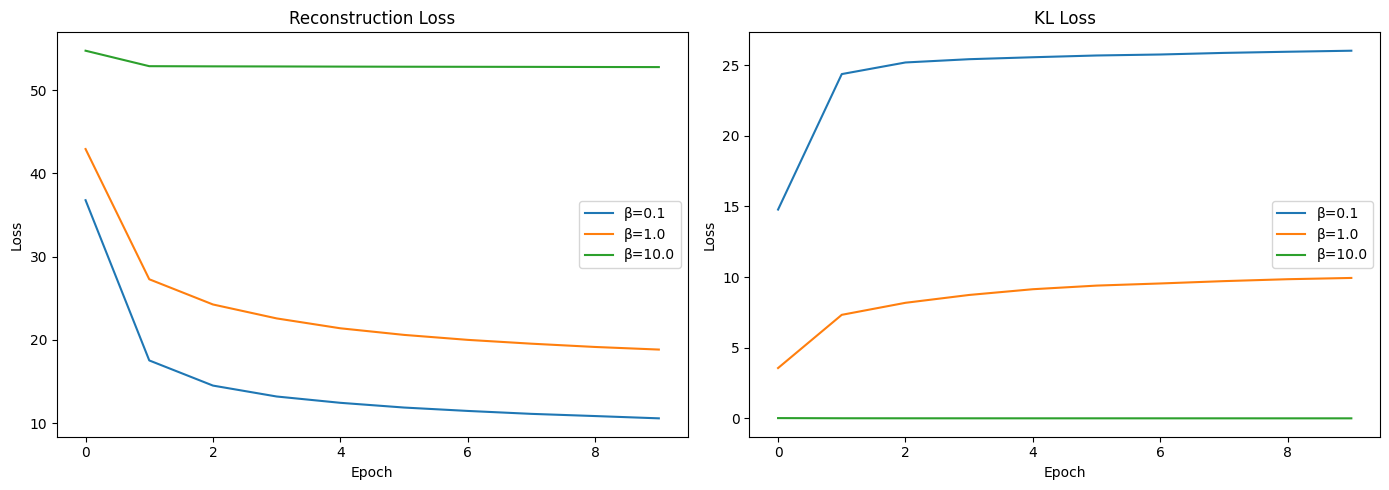

In [18]:
betas    = [0.1, 1.0, 10.0]
histories = {}
models_beta = {}

for beta in betas:
    m = VAE().to(DEVICE)
    o = optim.Adam(m.parameters(), lr=LR)
    h = train(m, o, vae_loss, train_loader, beta=beta)
    histories[beta] = h
    models_beta[beta] = m

# Plot reconstruction and KL loss curves for all three β values
# YOUR PLOT HERE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for beta, h in histories.items():
    axes[0].plot(h['recon'], label=f'β={beta}')
    axes[1].plot(h['kl'],    label=f'β={beta}')
axes[0].set_title('Reconstruction Loss'); axes[0].legend()
axes[1].set_title('KL Loss');             axes[1].legend()
for ax in axes: ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
plt.tight_layout(); plt.show()

### Q3.2 — Posterior Collapse Analysis (15 pts)

Posterior collapse occurs when the encoder ignores the input and maps everything to the prior: $q_\phi(z|x) \approx p(z)$ regardless of $x$.

1. For each trained model, use `compute_active_dims` below to compute the per-dimension variance of the encoder means across the test set.
2. For each $\beta$, show a plot of the per-dimension variance across all 20 latent dimensions.
3. What happens to the latent dimensions under $\beta = 10.0$? Provide a explanation why does a large $\beta$ incentivize the encoder to ignore the input? Why does the decoder then receive no useful signal from those dimensions?

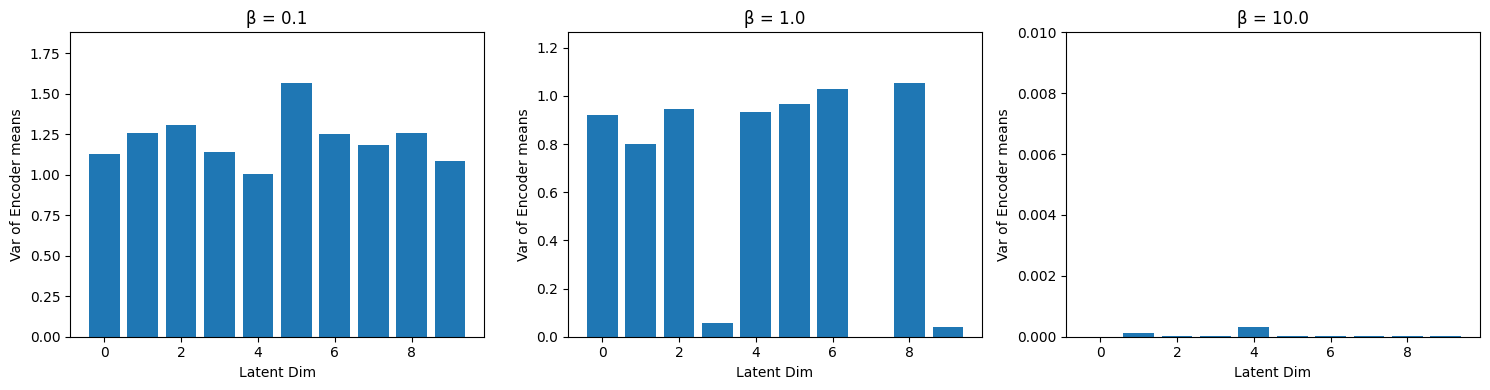

In [ ]:
def compute_active_dims(model, loader, device=DEVICE):
    """
    Returns: (z_dim,) tensor — per-dimension variance of encoder means
    across the test set.
    """
    model.eval()
    all_mu = []
    with torch.no_grad():
        for x, _ in loader:
            mu, _ = model.encoder(x.to(device))
            all_mu.append(mu.cpu())
    all_mu = torch.cat(all_mu, dim=0)   # (N_test, z_dim)
    return all_mu.var(dim=0)            # (z_dim,)


# Compute and plot active dimensions for each β
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, beta in enumerate(betas):
    var = compute_active_dims(models_beta[beta], test_loader)
    axes[i].bar(range(len(var)), var.numpy())
    axes[i].set_title(f'β = {beta}')
    axes[i].set_xlabel('Latent Dim')
    axes[i].set_ylabel('Var of Encoder means')
    
    if i == 2:
        # we set the scale of the last graph to 0.01 so that it is visible a bit
        axes[i].set_ylim(0, 0.01)
    else:
        # Standard scaling for the first two
        axes[i].set_ylim(0, max(var.max().item() * 1.2, 0.1))

plt.tight_layout()
plt.show()

---
## Part 4  Geometry of the Latent Space

### Q4.1  Linear Interpolation (15 pts)

A well-trained VAE should produce a smooth, connected latent space: nearby points in $\mathbb{R}^d$ should decode to semantically similar images.

Using your $\beta = 1.0$ model:

1. Pick one test image of digit "2" and one of digit "7". Pass each through the encoder and record the **mean vectors** $\mu_A$ and $\mu_B$ (use the mean, not a sample).
2. Generate 10 interpolated latent vectors: $z_t = (1-t)\,\mu_A + t\,\mu_B,\quad t \in \{0.0,\,0.1,\,\ldots,\,1.0\}$
3. Decode each $z_t$ and display the resulting images.
4. Do you observe a smooth semantic transition? Describe what the intermediate images look like. Why does the KL regularization term play a direct role in enabling this, while a standard Autoencoder (no KL term) would not guarantee it?

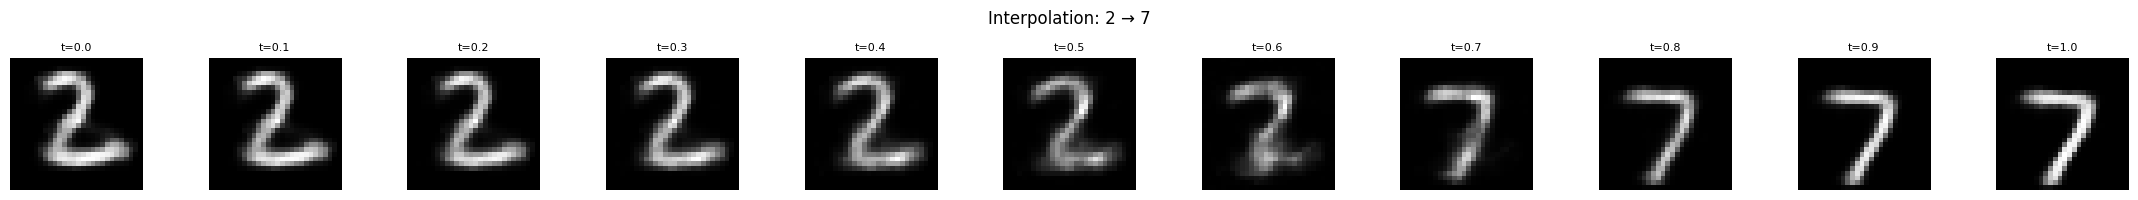

In [22]:
# YOUR CODE HERE
model_b1 = models_beta[1.0]
model_b1.eval()

# Find a "2" and a "7" from test set
idx_2, idx_7 = None, None
for i, (_, label) in enumerate(test_dataset):
    if label == 2 and idx_2 is None: idx_2 = i
    if label == 7 and idx_7 is None: idx_7 = i
    if idx_2 is not None and idx_7 is not None: break

x_A = test_dataset[idx_2][0].unsqueeze(0).to(DEVICE)
x_B = test_dataset[idx_7][0].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    mu_A, _ = model_b1.encoder(x_A)
    mu_B, _ = model_b1.encoder(x_B)

ts = torch.linspace(0, 1, 11)
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
for i, t in enumerate(ts):
    z_t = (1 - t) * mu_A + t * mu_B
    with torch.no_grad():
        img = model_b1.decoder(z_t).cpu().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f't={t:.1f}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('Interpolation: 2 → 7'); plt.tight_layout(); plt.show()


### Q4.2 — 2-D Latent Space Visualization *(Bonus, 10 pts)*

Retrain a VAE with `Z_DIM = 2`. Encode the full test set, collect all $\mu$ vectors, and plot them colored by digit class. Describe the structure: are digit classes separated? Do visually similar digits cluster near each other?

Epoch 1/10 | Total: 48.2967 | Recon: 46.1576 | KL: 2.1391
Epoch 2/10 | Total: 40.6134 | Recon: 36.8792 | KL: 3.7342
Epoch 3/10 | Total: 38.8387 | Recon: 34.6637 | KL: 4.1751
Epoch 4/10 | Total: 37.8416 | Recon: 33.4052 | KL: 4.4365
Epoch 5/10 | Total: 37.1687 | Recon: 32.5644 | KL: 4.6044
Epoch 6/10 | Total: 36.6503 | Recon: 31.9144 | KL: 4.7359
Epoch 7/10 | Total: 36.2844 | Recon: 31.4456 | KL: 4.8388
Epoch 8/10 | Total: 35.9749 | Recon: 31.0551 | KL: 4.9198
Epoch 9/10 | Total: 35.7461 | Recon: 30.7701 | KL: 4.9760
Epoch 10/10 | Total: 35.5224 | Recon: 30.4935 | KL: 5.0288


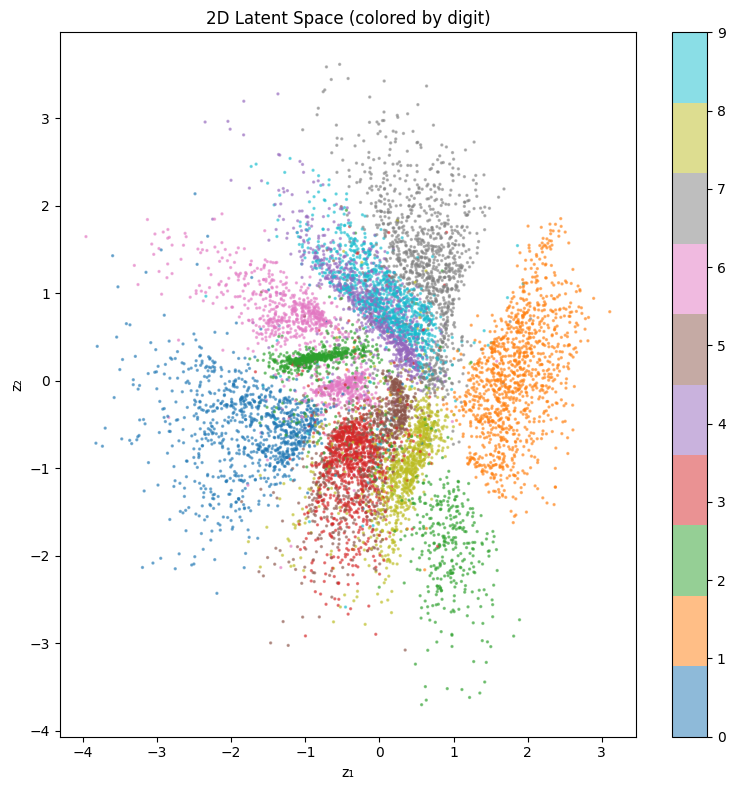

In [23]:
# YOUR CODE HERE
model_2d = VAE(z_dim=2).to(DEVICE)
opt_2d = optim.Adam(model_2d.parameters(), lr=LR)
train(model_2d, opt_2d, vae_loss, train_loader, epochs=EPOCHS)

model_2d.eval()
all_mu, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model_2d.encoder(x.to(DEVICE))
        all_mu.append(mu.cpu()); all_labels.append(y)
all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(8, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels,
                       cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel('z₁'); plt.ylabel('z₂')
plt.title('2D Latent Space (colored by digit)')
plt.tight_layout(); plt.show()


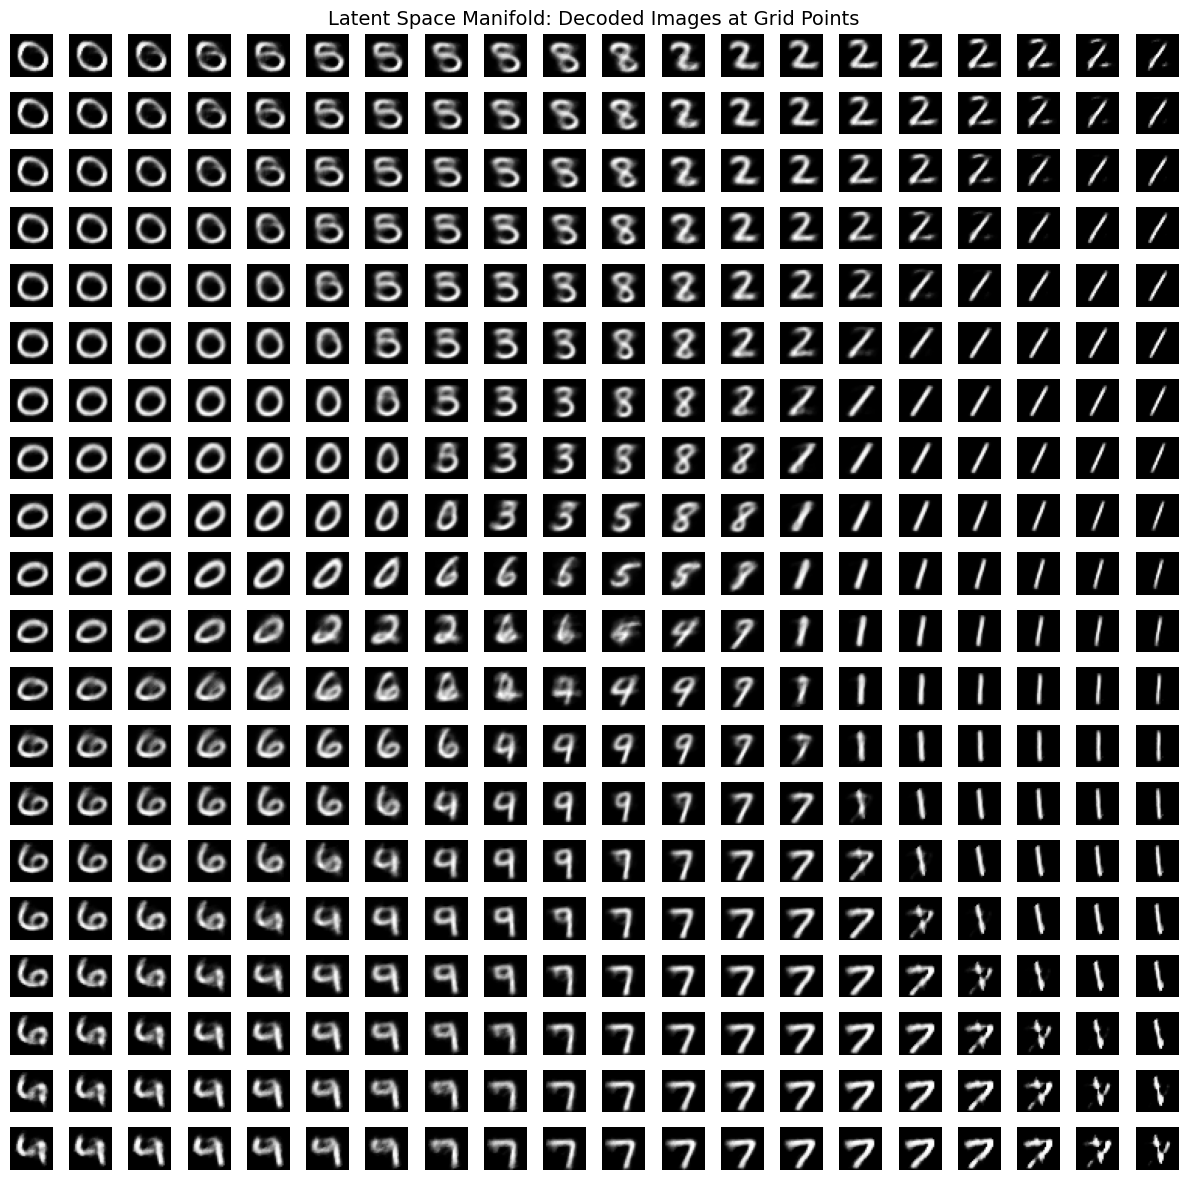

In [ ]:
# Show the latent space as a grid of decoded images (extra)
n_points = 20
x_range = np.linspace(-3, 3, n_points)
y_range = np.linspace(-3, 3, n_points)

fig, axes = plt.subplots(n_points, n_points, figsize=(12, 12))
model_2d.eval()

with torch.no_grad():
    for i, y in enumerate(y_range):
        for j, x in enumerate(x_range):
            z = torch.tensor([[x, y]], dtype=torch.float32).to(DEVICE)
            img = model_2d.decoder(z).cpu().squeeze()
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

plt.suptitle('Latent Space Manifold: Decoded Images at Grid Points', fontsize=14)
plt.tight_layout()
plt.show()